In [1]:
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform_pytorch_inplace
import torch
import unittest
from tqdm.auto import tqdm
from nn_supervised_reproduction import (
    get_config,
    output_dir,
    default_config
)
from misc_utils import read_jsonl_to_df, keep_serializable, column_to

In [2]:
df = read_jsonl_to_df(output_dir.glob('*/results.jsonl')).fillna(keep_serializable(default_config))

In [3]:
df

,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,batch_size,shuffle,lattice,test_overlap,train_loss,epoch,J2,eps_train,test_accuracy,start_timestamp,current_timestamp
0,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.011403,0.697866,0,0.0,0.0100,NaN,NaN,NaN
1,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.150362,0.690074,1,0.0,0.0100,NaN,NaN,NaN
2,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.359211,0.656764,2,0.0,0.0100,NaN,NaN,NaN
3,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.632655,0.572671,3,0.0,0.0100,NaN,NaN,NaN
4,50000,6.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,0.824368,0.435468,4,0.0,0.0100,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609427,50000,10.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.078276,0.000699,995,1.0,0.0001,0.49498,20231012_043259,20231012_083428
609428,50000,10.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.072471,0.000729,996,1.0,0.0001,0.49502,20231012_043259,20231012_083429
609429,50000,10.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.082003,0.000732,997,1.0,0.0001,0.49500,20231012_043259,20231012_083429
609430,50000,10.0,dense,512,1,1000,1,0.001,64,True,kagome2x4,-0.081454,0.000678,998,1.0,0.0001,0.49478,20231012_043259,20231012_083429


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


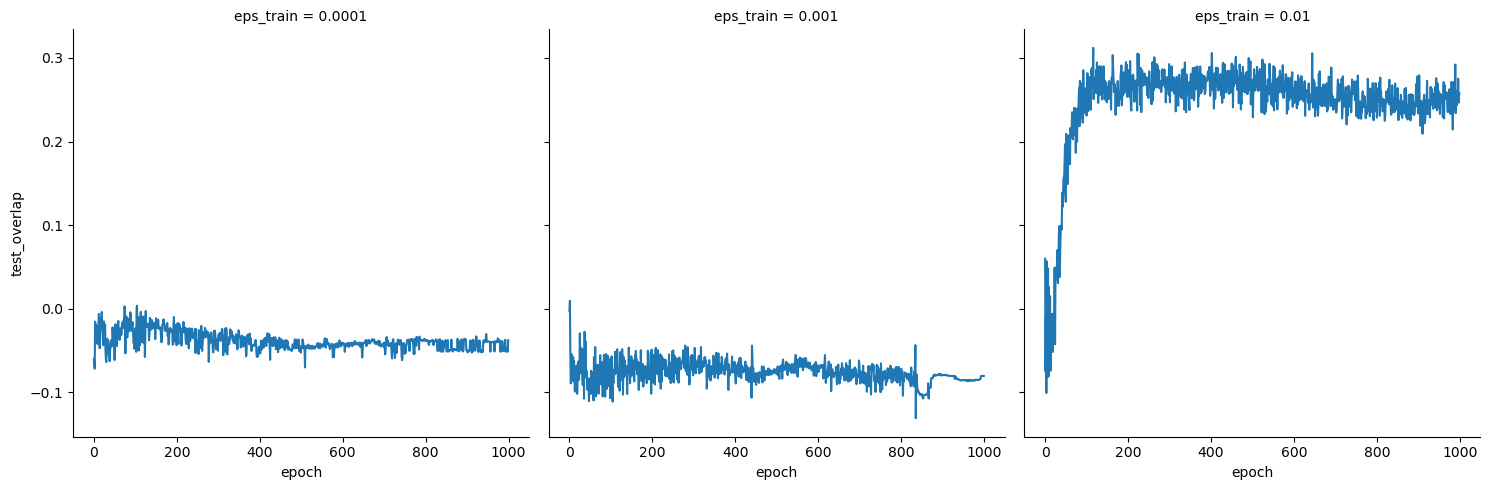

In [17]:
sns.relplot(
    df.query('(lattice == "kagome2x4" and J2 == 1  and sampling_power_train == 2 )'),
    x='epoch',
    y='test_overlap', kind='line', col='eps_train')


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


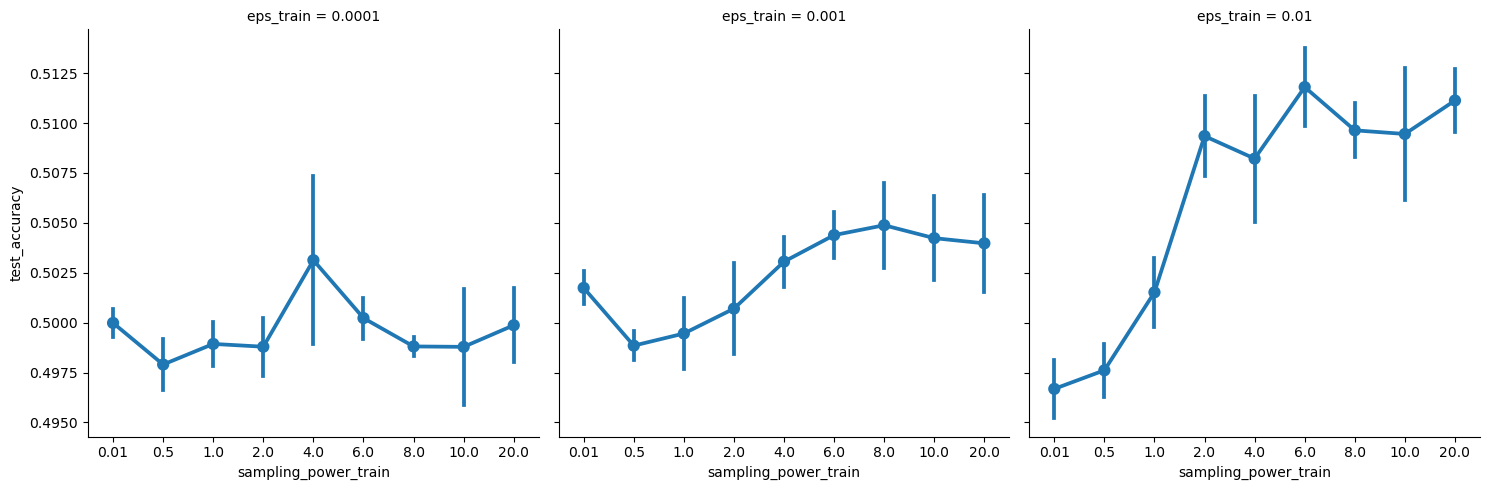

In [10]:
sns.catplot(
    (
        df.query('(lattice == "kagome2x4" and J2 >= 0.8 and epoch >= 200)')
    ),
    x="sampling_power_train",
    y="test_accuracy",
    col="eps_train",
    kind='point',
    errorbar='sd',
)
#plt.savefig("fig/fourier_supervised_cleanroom-overlap-vs-sampling_power_train.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


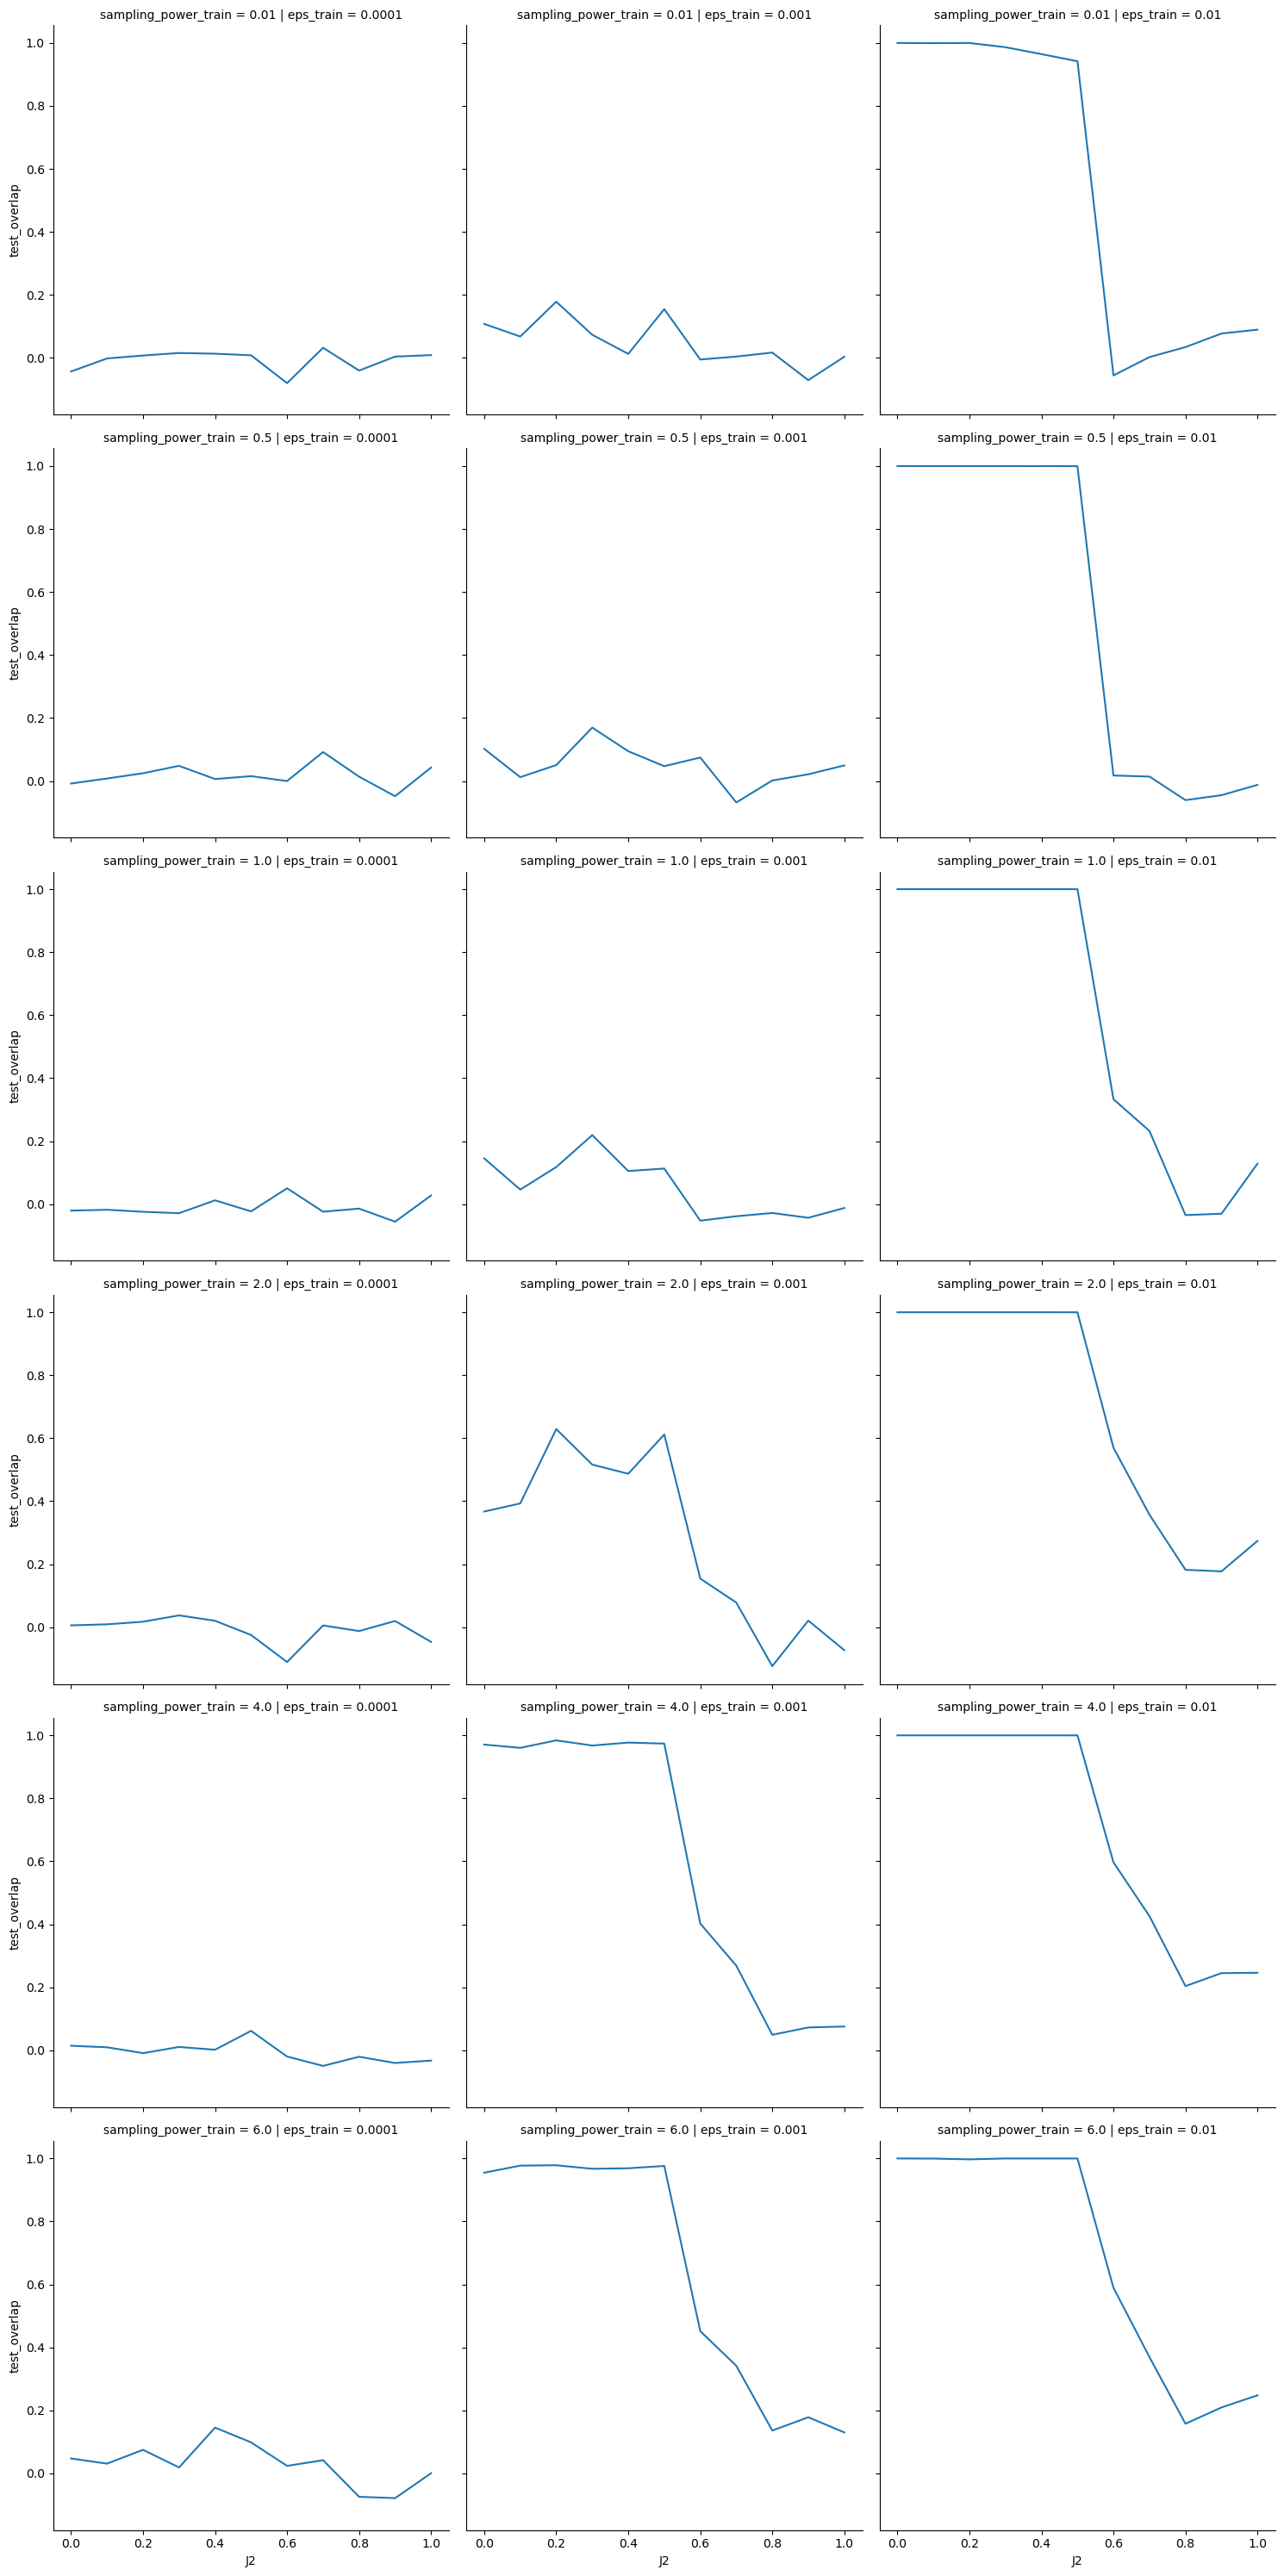

In [32]:
sns.relplot(
    df.query('lattice == "kagome2x4" and epoch == 500'),
    x="J2",
    y="test_overlap",
    col='eps_train',
    kind='line',
    row='sampling_power_train',
)